In [2]:
import numpy as np
import matplotlib.pyplot as plt

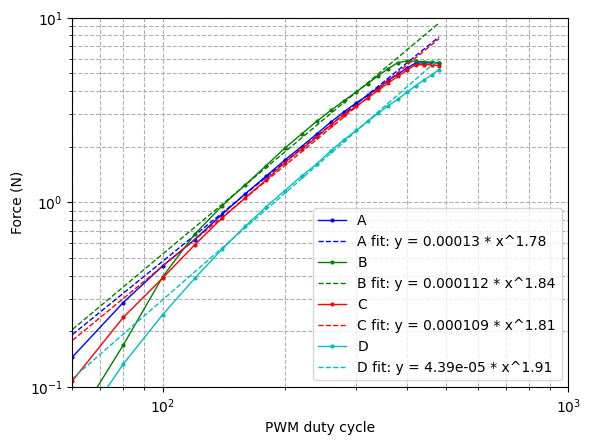

In [24]:
# plot A B C D

datasets = ["A", "B", "C", "D"]

colours = ['b', 'g', 'r', 'c' , 'm', 'y', 'k']

for dataset in datasets:
    try:
        with open(f"{dataset}.txt", "r") as f:
            data = f.read().splitlines()
    except FileNotFoundError:
        print(f"File {dataset}.txt not found")
        continue

    speedlist = []
    forcelist = []

    for line in data:
        speedraw, forceraw = line.split(',')
        speedstr = speedraw.split(':')[1].strip()
        forcestr = forceraw.split(':')[1].strip()

        speed = float(speedstr)
        force = float(forcestr)

        speedlist.append(speed)
        forcelist.append(force)

    c = colours.pop(0)
    
    plt.loglog(speedlist, forcelist, label=dataset, marker='o', markersize=2, linewidth=1, color=c)
    # plot linear fit line
    speedlist = np.array(speedlist)
    speedlist_f = speedlist[np.bitwise_and(100 < speedlist, speedlist < 400)]
    x = np.log10(speedlist_f)
    forcelist = np.array(forcelist)
    forcelist_f = forcelist[np.bitwise_and(100 < speedlist, speedlist < 400)]
    y = np.log10(forcelist_f)

    n, log_A = np.polyfit(x, y, 1)
    A = 10**log_A
    plt.loglog(speedlist, A * speedlist**n, linestyle='--',
               label=f"{dataset} fit: y = {A:.3g} * x^{n:.2f}", color=c, linewidth=1)

plt.xlim(60, 1e3)
plt.ylim(1e-1, 1e1)

plt.xlabel("PWM duty cycle")
plt.ylabel("Force (N)")

plt.grid(which='both', linestyle='--')
plt.legend()

plt.savefig("power_law.png", dpi=300)
